In [216]:
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris, load_wine
import warnings
import platform

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [217]:
df_c = pd.read_csv("../data/olist_customers_dataset.csv")
df_g = pd.read_csv("../data/olist_geolocation_dataset.csv")
df_oi = pd.read_csv("../data/olist_order_items_dataset.csv")
df_op = pd.read_csv("../data/olist_order_payments_dataset.csv")
df_or = pd.read_csv("../data/olist_order_reviews_dataset.csv")
df_o = pd.read_csv("../data/olist_orders_dataset.csv")
df_p = pd.read_csv("../data/olist_products_dataset.csv")
df_s = pd.read_csv("../data/olist_sellers_dataset.csv")

# 1. seller_state 분포

In [218]:
# seller_state 분포
seller_state_cnt = df_s['seller_state'].value_counts()
seller_state_cnt

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [219]:
# seller_state 비율
seller_state_ratio = df_s['seller_state'].value_counts(normalize=True)
print(seller_state_ratio)
print(f"\n[top2]\n{seller_state_ratio.head(2).sum().round(2)}%")

seller_state
SP    0.597415
PR    0.112763
MG    0.078837
SC    0.061389
RJ    0.055250
RS    0.041680
GO    0.012924
DF    0.009693
ES    0.007431
BA    0.006139
CE    0.004200
PE    0.002908
PB    0.001939
RN    0.001616
MS    0.001616
MT    0.001292
RO    0.000646
SE    0.000646
AC    0.000323
PI    0.000323
MA    0.000323
AM    0.000323
PA    0.000323
Name: proportion, dtype: float64

[top2]
0.71%


> 상위 2개의 지역이 전체의 70% 이상을 차지함

<Axes: xlabel='seller_state', ylabel='count'>

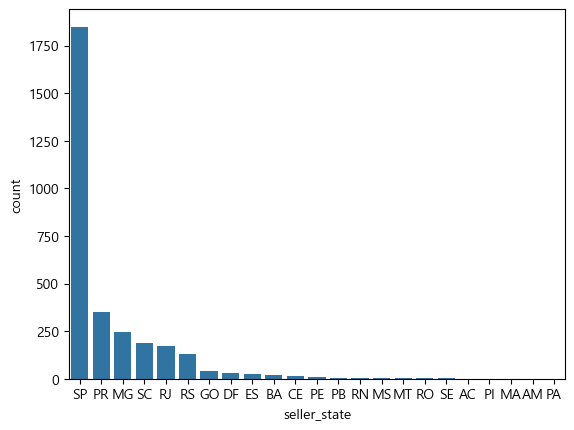

In [220]:
sns.countplot(data=df_s, x="seller_state",
              order=df_s['seller_state'].value_counts().index)

> SP에 집중되어 있음

---
# 2. seller vs customer 분포

- 고객이 많은 지역에 seller도 충분히 존재하는가?

In [221]:
# customer 지역 분포
customer_state_cnt = df_c['customer_state'].value_counts()
customer_state_cnt

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [222]:
# seller vs customer 비교
compare_df = pd.concat(
    [seller_state_cnt, customer_state_cnt],
    axis=1
)

compare_df.columns = ['seller_cnt','customer_cnt']
compare_df = compare_df.fillna(0)

# int 변환
compare_df[['seller_cnt','customer_cnt']] = compare_df[['seller_cnt','customer_cnt']].astype(int)

# 비율 계산
## 고객 1명당 판매자가 얼마나 존재하나?
compare_df['seller_customer_ratio'] = compare_df['seller_cnt'] / compare_df['customer_cnt']

# ratio 내림차순 정렬
compare_df = compare_df.sort_values(by='seller_customer_ratio', ascending=False)

compare_df

,seller_cnt,customer_cnt,seller_customer_ratio
PR,349,5045,0.069177
SC,190,3637,0.052241
SP,1849,41746,0.044292
RS,129,5466,0.023600
MG,244,11635,0.020971
GO,40,2020,0.019802
DF,30,2140,0.014019
RJ,171,12852,0.013305
AC,1,81,0.012346
ES,23,2033,0.011313


<Axes: >

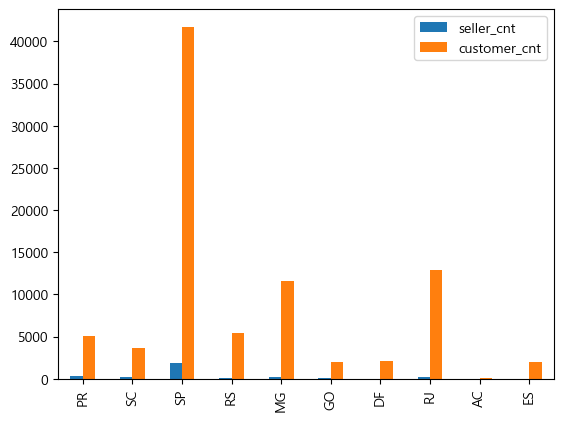

In [223]:
compare_df[['seller_cnt','customer_cnt']].head(10).plot(kind='bar')

- seller와 customer의 불균형이 큰 의미가 있을까?
    - customer가 본인의 지역의 물건을 많이 구매해야만 의미가 생기나?

---
# 3. 카테고리 구조 분석

In [224]:
# 번역
data = {
    "product_category_name": [
        "beleza_saude","informatica_acessorios","automotivo","cama_mesa_banho","moveis_decoracao",
        "esporte_lazer","perfumaria","utilidades_domesticas","telefonia","relogios_presentes",
        "alimentos_bebidas","bebes","papelaria","tablets_impressao_imagem","brinquedos",
        "telefonia_fixa","ferramentas_jardim","fashion_bolsas_e_acessorios","eletroportateis",
        "consoles_games","audio","fashion_calcados","cool_stuff","malas_acessorios",
        "climatizacao","construcao_ferramentas_construcao",
        "moveis_cozinha_area_de_servico_jantar_e_jardim",
        "construcao_ferramentas_jardim","fashion_roupa_masculina","pet_shop","moveis_escritorio",
        "market_place","eletronicos","eletrodomesticos","artigos_de_festas","casa_conforto",
        "construcao_ferramentas_ferramentas","agro_industria_e_comercio",
        "moveis_colchao_e_estofado","livros_tecnicos","casa_construcao","instrumentos_musicais",
        "moveis_sala","construcao_ferramentas_iluminacao",
        "industria_comercio_e_negocios","alimentos","artes","moveis_quarto",
        "livros_interesse_geral","construcao_ferramentas_seguranca",
        "fashion_underwear_e_moda_praia","fashion_esporte","sinalizacao_e_seguranca",
        "pcs","artigos_de_natal","fashion_roupa_feminina","eletrodomesticos_2",
        "livros_importados","bebidas","cine_foto","la_cuisine","musica","casa_conforto_2",
        "portateis_casa_forno_e_cafe","cds_dvds_musicais","dvds_blu_ray","flores",
        "artes_e_artesanato","fraldas_higiene","fashion_roupa_infanto_juvenil",
        "seguros_e_servicos"
    ],

    "product_category_name_en": [
        "health_beauty","computers_accessories","auto","bed_bath_table","furniture_decor",
        "sports_leisure","perfumery","housewares","telephony","watches_gifts",
        "food_drink","baby","stationery","tablets_printing_image","toys",
        "fixed_telephony","garden_tools","fashion_bags_accessories","small_appliances",
        "consoles_games","audio","fashion_shoes","cool_stuff","luggage_accessories",
        "air_conditioning","construction_tools_construction",
        "kitchen_dining_laundry_garden_furniture",
        "construction_tools_garden","fashion_male_clothing","pet_shop","office_furniture",
        "market_place","electronics","home_appliances","party_supplies","home_confort",
        "construction_tools_tools","agro_industry_and_commerce",
        "furniture_mattress_and_upholstery","books_technical","home_construction",
        "musical_instruments","furniture_living_room",
        "construction_tools_lights","industry_commerce_and_business","food","art",
        "furniture_bedroom","books_general_interest",
        "construction_tools_safety","fashion_underwear_beach","fashion_sport",
        "signaling_and_security","computers","christmas_supplies","fashion_female_clothing",
        "home_appliances_2","books_imported","drinks","cine_photo","la_cuisine","music",
        "home_comfort_2","small_appliances_home_oven_and_coffee",
        "cds_dvds_musicals","dvds_blu_ray","flowers","arts_and_craftmanship",
        "diapers_and_hygiene","fashion_childrens_clothes","security_and_services"
    ],

    "product_category_name_kr": [
        "헬스·뷰티","컴퓨터 액세서리","자동차 용품","침대·욕실·테이블","가구·인테리어",
        "스포츠·레저","향수","생활용품","전화기","시계·선물",
        "식음료","유아용품","문구류","태블릿·프린터","장난감",
        "유선 전화기","정원 도구","패션 가방·액세서리","소형 가전",
        "콘솔 게임","오디오","패션 신발","아이디어 상품","여행 가방·액세서리",
        "에어컨·냉난방","건설 공구",
        "주방·식당·세탁·정원 가구",
        "정원 공구","남성 의류","반려동물 용품","사무용 가구",
        "마켓플레이스 상품","전자제품","대형 가전","파티 용품","홈 인테리어",
        "건설 공구(일반)","농업·산업 장비",
        "매트리스·소파 가구","기술 서적","주택 건축",
        "악기","거실 가구",
        "조명 공구","산업·상업 장비","식품","예술 작품",
        "침실 가구","일반 서적",
        "안전 공구","언더웨어·비치웨어","스포츠 패션",
        "안전 표지·보안","컴퓨터","크리스마스 용품","여성 의류",
        "대형 가전(기타)","수입 서적","음료","사진·영상","프랑스 요리 도구","음악",
        "홈 인테리어(기타)","소형 주방가전(오븐·커피)",
        "음악 CD·DVD","블루레이 DVD","꽃","예술·공예",
        "기저귀·위생용품","아동 의류","보험·서비스"
    ]
}

df_category_translation = pd.DataFrame(data)

## merge는 한 번만 해야함
df_p = df_p.merge(
    df_category_translation,
    on='product_category_name',
    how='left'
)

df_p[['product_category_name',
      'product_category_name_en',
      'product_category_name_kr']].head()

,product_category_name,product_category_name_en,product_category_name_kr
0,perfumaria,perfumery,향수
1,artes,art,예술 작품
2,esporte_lazer,sports_leisure,스포츠·레저
3,bebes,baby,유아용품
4,utilidades_domesticas,housewares,생활용품


In [225]:
# 카테고리 주문 수 확인
print(f"[카테고리 수]\n{df_p['product_category_name'].nunique()}개\n")
category_cnt = df_p['product_category_name_kr'].value_counts()
print(f"[카테고리 주문 수 top20]\n{category_cnt.head(20)}")

[카테고리 수]
73개

[카테고리 주문 수 top20]
product_category_name_kr
침대·욕실·테이블     3029
스포츠·레저        2867
가구·인테리어       2657
헬스·뷰티         2444
생활용품          2335
자동차 용품        1900
컴퓨터 액세서리      1639
장난감           1411
시계·선물         1329
전화기           1134
유아용품           919
향수             868
문구류            849
패션 가방·액세서리     849
아이디어 상품        789
정원 도구          753
반려동물 용품        719
전자제품           517
건설 공구          400
대형 가전          370
Name: count, dtype: int64


---
# 4. region x category 분석

In [226]:
df1 = df_oi.merge(df_p, on="product_id")
df1 = df1.merge(df_s, on="seller_id")

In [227]:
state_category = df1.groupby(
    ["seller_state","product_category_name_kr"]
).size().reset_index(name="order_cnt")
state_category.head()

,seller_state,product_category_name_kr,order_cnt
0,AC,기술 서적,1
1,AM,전화기,3
2,BA,가구·인테리어,1
3,BA,반려동물 용품,2
4,BA,스포츠·레저,30


In [228]:
pivot = df1.pivot_table(
    index="seller_state",
    columns="product_category_name_kr",
    values="order_id",
    aggfunc="count",
    fill_value=0
)
pivot.head(5)

product_category_name_kr,가구·인테리어,거실 가구,건설 공구,건설 공구(일반),기술 서적,기저귀·위생용품,꽃,남성 의류,농업·산업 장비,대형 가전,...,크리스마스 용품,태블릿·프린터,파티 용품,패션 가방·액세서리,패션 신발,프랑스 요리 도구,향수,헬스·뷰티,홈 인테리어,홈 인테리어(기타)
seller_state,,,,,,,,,,,,,,,,,,,,,
AC,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AM,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BA,1,0,0,0,0,0,0,0,0,0,...,0,0,0,16,0,0,0,16,0,0
CE,6,1,0,0,3,0,0,0,1,0,...,0,0,0,1,0,0,0,30,0,0
DF,25,7,12,0,0,0,0,0,0,1,...,0,0,0,33,2,0,32,139,0,0


<Axes: xlabel='product_category_name_kr', ylabel='seller_state'>

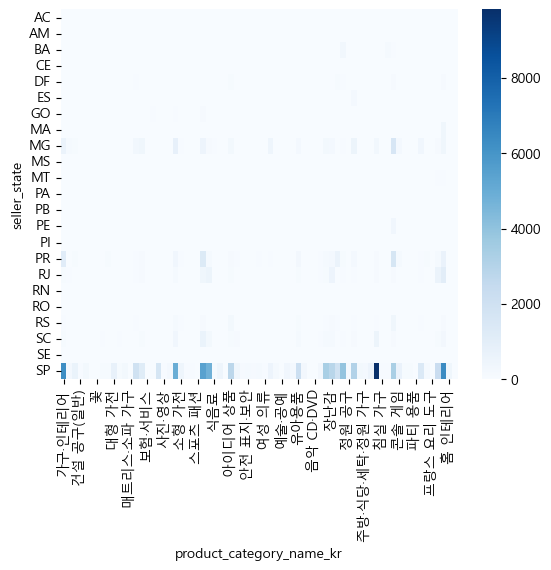

In [ ]:
sns.heatmap(pivot, cmap="Blues")
## 모든 카테고리가 보이지 않는다

In [230]:
state_top_category = df1.groupby(
    ["seller_state","product_category_name_kr"]
).size().groupby(level=0).idxmax()
state_top_category

seller_state
AC        (AC, 기술 서적)
AM          (AM, 전화기)
BA          (BA, 전화기)
CE        (CE, 헬스·뷰티)
DF     (DF, 컴퓨터 액세서리)
ES        (ES, 정원 도구)
GO       (GO, 스포츠·레저)
MA        (MA, 헬스·뷰티)
MG     (MG, 컴퓨터 액세서리)
MS       (MS, 자동차 용품)
MT           (MT, 향수)
PA       (PA, 스포츠·레저)
PB        (PB, 시계·선물)
PE     (PE, 컴퓨터 액세서리)
PI       (PI, 자동차 용품)
PR     (PR, 컴퓨터 액세서리)
RJ        (RJ, 헬스·뷰티)
RN        (RN, 일반 서적)
RO       (RO, 자동차 용품)
RS     (RS, 컴퓨터 액세서리)
SC       (SC, 스포츠·레저)
SE    (SE, 침대·욕실·테이블)
SP    (SP, 침대·욕실·테이블)
dtype: object

In [231]:
category_state = df1.groupby(
    ["product_category_name_kr","seller_state"]
).size().reset_index(name='count')

category_state.head()

,product_category_name_kr,seller_state,count
0,가구·인테리어,BA,1
1,가구·인테리어,CE,6
2,가구·인테리어,DF,25
3,가구·인테리어,ES,7
4,가구·인테리어,GO,1


---
# 5. seller 활동량 분석

In [232]:
# 판매자별 판매 건수
seller_activity = df_oi.groupby('seller_id').size()
seller_activity.sort_values(ascending=False).head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
dtype: int64

In [233]:
seller_activity.describe()

count    3095.000000
mean       36.397415
std       119.193461
min         1.000000
25%         2.000000
50%         8.000000
75%        24.000000
max      2033.000000
dtype: float64

<Axes: ylabel='Count'>

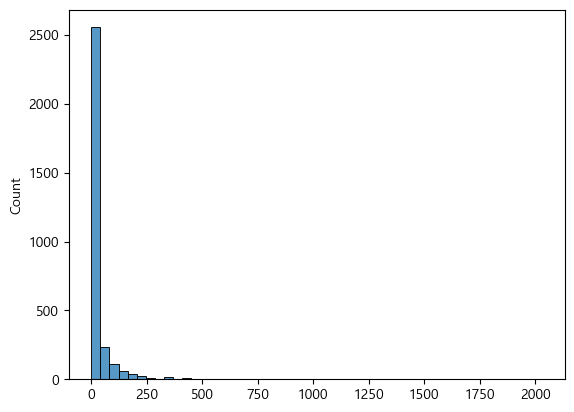

In [234]:
sns.histplot(seller_activity, bins=50)

In [235]:
# 상위 n명이 전체 판매에서 차지하는 비중
top10_share = seller_activity.sort_values(ascending=False).head(10).sum() / seller_activity.sum()
top20_share = seller_activity.sort_values(ascending=False).head(20).sum() / seller_activity.sum()
top30_share = seller_activity.sort_values(ascending=False).head(30).sum() / seller_activity.sum()
display(top10_share)
display(top20_share)
display(top30_share)

np.float64(0.1415179760319574)

np.float64(0.21641367066134043)

np.float64(0.26423435419440744)

In [236]:
df2 = df_oi.merge(df_s, on="seller_id")

In [237]:
# 판매자 지역별 주문 활동량 분석
state_activity = df2.groupby("seller_state")['order_id'].count()
state_activity.sort_values(ascending=False)

seller_state
SP    80342
MG     8827
PR     8671
RJ     4818
SC     4075
RS     2199
DF      899
BA      643
GO      520
PE      448
MA      405
ES      372
MT      145
CE       94
RN       56
MS       50
PB       38
RO       14
PI       12
SE       10
PA        8
AM        3
AC        1
Name: order_id, dtype: int64

<Axes: xlabel='seller_state'>

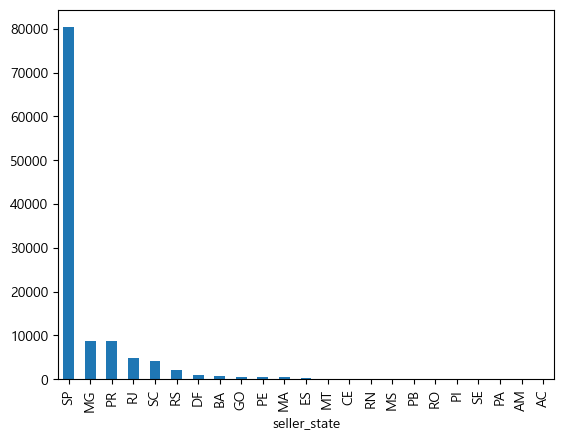

In [238]:
state_activity.sort_values(ascending=False).plot(kind="bar")